# Optimization Benchmark given different Perturbation to the Original Field
Ported from MATLAB: spectral_main.m + 6 helper .m files.

All operations are 2D spectral (surface only).
Uses JAX for JIT compilation, GPU acceleration, and auto-differentiation.

In [78]:
# Packages

import jax
# Enable 64-bit
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import jit
import jaxopt
import matplotlib
# matplotlib.use('Agg')          # headless, no Tk
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tkinter as tk
from tkinter import filedialog
import scipy.io as sio
import sys
import dill
import inspect

# For fourier transform
from numpy.fft import rfft2, irfft2

# Input subfiles
%reload_ext autoreload
%autoreload 2

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), '..'))
from physics_functions import calculate_surface_u, forward_ssh
from cost_functions import cost_function_fmin
from ssh_setup import ssh_setup


# print(inspect.getsource(perturb_C2_cutoff))



In [79]:
# # Reload the data
# import dill
# import tkinter as tk
# from tkinter import filedialog
# import numpy as np

# root = tk.Tk(); root.withdraw(); root.attributes("-topmost", True)
# pkl_path = filedialog.askopenfilename(
#     title="Select a workspace .pkl file to load",
#     filetypes=[("Pickle files", "*.pkl"), ("All files", "*.*")],
# )
# root.destroy()

# if not pkl_path:
#     print("No file selected.")
# else:
#     with open(pkl_path, 'rb') as f:
#         ws = dill.load(f)
#     print(f"Loaded: {pkl_path}\n")

#     def describe(value):
#         """Return a short string describing the type/shape of a value."""
#         if isinstance(value, np.ndarray):
#             return f"ndarray  shape={value.shape}  dtype={value.dtype}"
#         if hasattr(value, 'shape') and hasattr(value, 'dtype'):  # jax arrays, etc.
#             return f"{type(value).__name__}  shape={tuple(value.shape)}  dtype={value.dtype}"
#         if isinstance(value, dict):
#             return f"dict  (len={len(value)})"
#         if isinstance(value, (list, tuple)):
#             return f"{type(value).__name__}  (len={len(value)})"
#         if isinstance(value, (int, float, complex, bool, str)):
#             return f"{type(value).__name__} = {value!r}"
#         return type(value).__name__

#     print(f"Top-level keys ({len(ws)}):")
#     print("-" * 72)
#     for k, v in ws.items():
#         print(f"  {k:<22}  {describe(v)}")

#     # Drill one level into dicts (cases, benchmark_results, phi0_s_optimals, ...)
#     print("\nNested structure (one level deep):")
#     print("-" * 72)
#     for k, v in ws.items():
#         if isinstance(v, dict) and len(v) > 0:
#             print(f"\n  {k}:")
#             for sub_k, sub_v in v.items():
#                 if isinstance(sub_v, tuple):
#                     inner = ", ".join(describe(x) for x in sub_v)
#                     print(f"    {sub_k:<22}  tuple({inner})")
#                 elif isinstance(sub_v, dict):
#                     inner_keys = ", ".join(sub_v.keys())
#                     print(f"    {sub_k:<22}  dict  keys=[{inner_keys}]")
#                 else:
#                     print(f"    {sub_k:<22}  {describe(sub_v)}")

#     # Inject into globals so the rest of the notebook can use the loaded variables
#     globals().update(ws)
#     print("\nAll keys injected into globals().")

# Load the Data and Setup Parameter

In [80]:
# Key Parameters

# This is the scale for perturbation

# For correction term
Ro_sys = 1e-1

# This is the scale of the perturbation.
epsilon = 1e-2

In [81]:
import sys

print("Select an SSH data file (.mat)... Press Cancel to use default SSH_setup")
root = tk.Tk()
root.withdraw()

file_path = filedialog.askopenfilename(
    title="Select an SSH data file (.mat)",
    filetypes=[("MATLAB Data Files", "*.mat"), ("All Files", "*.*")]
)

mat_contents = sio.loadmat(file_path)
# Find the relevant array (expecting buoyancy 'bout')
key = 'bout'
b_s_data = mat_contents[key]
b_s = b_s_data[:, :, -1]
print(f"Loaded 3D buoyancy data from {file_path}, using the last period.")

# Normalization
b_s_normalized = b_s / jnp.max(jnp.abs(b_s))

Nx, Ny = b_s_normalized.shape
print(f"Grid size adjusted automatically to Nx={Nx}, Ny={Ny}.")
data_name = os.path.splitext(os.path.basename(file_path))[0]

Select an SSH data file (.mat)... Press Cancel to use default SSH_setup
Loaded 3D buoyancy data from D:/Documents/College/Research/Oceangrophy/Shafer_Project/SQG_Simulations/Shafer Simulation output/20260320_215523_Shafer_Simulation_random_IC/20260320_215523_Shafer_Simulation_random_IC.mat, using the last period.
Grid size adjusted automatically to Nx=512, Ny=512.


In [82]:
# Grid Setup
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Bu = 1.0
dx = Lx / Nx
dy = Ly / Ny
x = jnp.arange(Nx) * dx
y = jnp.arange(Ny) * dy
X, Y = jnp.meshgrid(x, y, indexing='ij')

# Spectral grid
dk = 1.0
dl = 1.0
k_zonal     = jnp.concatenate([jnp.arange(Nx//2), jnp.arange(-Nx//2, 0)]) * dk
l_meridional = jnp.concatenate([jnp.arange(Ny//2), jnp.arange(-Ny//2, 0)]) * dl
k_zonal      = k_zonal.at[Nx//2].set(0.0)      # kill Nyquist
l_meridional = l_meridional.at[Ny//2].set(0.0)
kx, ky = jnp.meshgrid(k_zonal, l_meridional, indexing='ij')

# The square of K
K2 = kx**2 + ky**2
K = jnp.sqrt(K2)

# Safe inverses (avoid division by zero at k=0)
inv_K = jnp.where(K > 0, 1.0 / K, 0.0)
inv_K2 = jnp.where(K2 > 0, 1.0 / K2, 0.0)

# This is for taking derivative in $z$ direction.
mu = jnp.sqrt(Bu) * K
inv_mu = jnp.where(mu > 0, 1.0 / mu, 0.0)


# True Sea Surface Height

From the Simulation, we have surface buoyancy $b^s$. Under non-dimensionalized setting, 

$$ b^s = \frac{\partial \psi}{\partial z} \Big|_{z = 0} $$

Then undere QG setting, 

$$ \eta^s = \psi^s $$

# Target Field

Now the Target Surface Sea Height should perhaps be the qg streamfunction adding the ageostrophic correction. That is 

$$ \eta_{tar} = \eta_{qg} + \epsilon \cdot \eta^1 $$

So a forward here is perform to generate the target field


In [83]:
def dealias_nyquist(field_hat, Nx, Ny):
    field_hat = field_hat.at[Nx // 2, :].set(0.0)
    field_hat = field_hat.at[:, Ny // 2].set(0.0)
    return field_hat


b_s_hat = jnp.fft.fft2(b_s_normalized)
b_s_hat = dealias_nyquist(b_s_hat, Nx, Ny)      
phi0_s_hat = b_s_hat * inv_mu
phi0_s_hat = dealias_nyquist(phi0_s_hat, Nx, Ny) 
phi0_s = jnp.real(jnp.fft.ifft2(phi0_s_hat))

ssh_qg = phi0_s
ssh_qg_hat = phi0_s_hat

eta_tar_hat = forward_ssh(ssh_qg_hat, kx, ky, mu, inv_mu, K2, inv_K2, Bu, Ro_sys)
eta_tar_hat = dealias_nyquist(eta_tar_hat, Nx, Ny)
eta_tar = jnp.real(jnp.fft.ifft2(eta_tar_hat))


# Plot the Energy Spectrum of Currnet Data

0.1


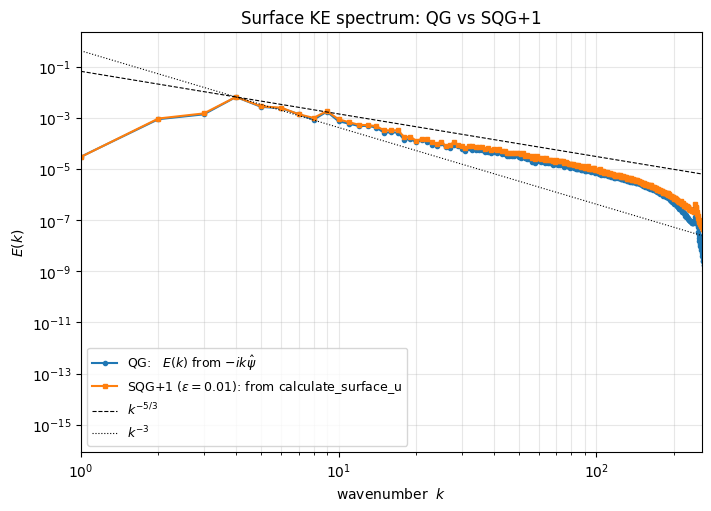

  <KE>_phys  QG    = 2.449091e-02   sum E_qg    = 2.449091e-02
  <KE>_phys  SQG+1 = 2.654979e-02   sum E_sqg1  = 2.654979e-02
  Total KE ratio (SQG+1 / QG) = 1.084067


In [84]:
# ── Surface KE spectrum: QG vs SQG+1 (first-order correction) ───────────────
# Compute u,v two ways from the same phi0_s_hat:
#   (a) QG:      u_hat = -i ky psi,   v_hat = i kx psi
#   (b) SQG+1:   u,v from calculate_surface_u, which adds the O(epsilon)
#                ageostrophic correction, then FFT back to spectral space.
# Azimuthally average |u_hat|^2 + |v_hat|^2 into integer-k bins.

import numpy as np

print(Ro_sys)

def azimuthal_ke(u_hat, v_hat, K, Nx, Ny):
    ke_2d = 0.5 * (jnp.abs(u_hat) ** 2 + jnp.abs(v_hat) ** 2) / (Nx * Ny) ** 2
    K_np  = np.array(K)
    ke_np = np.array(ke_2d)
    k_int = np.round(K_np).astype(int)
    k_max = int(k_int.max())
    ke_sum = np.zeros(k_max + 1)
    np.add.at(ke_sum, k_int.ravel(), ke_np.ravel())
    return np.arange(k_max + 1), ke_sum

# (a) QG velocity — purely geostrophic
u_qg_hat = -1j * ky * phi0_s_hat
v_qg_hat =  1j * kx * phi0_s_hat
k_axis, E_qg = azimuthal_ke(u_qg_hat, v_qg_hat, K, Nx, Ny)

# (b) SQG+1 velocity — includes O(epsilon) correction
u_s, v_s = calculate_surface_u(phi0_s_hat, mu, inv_mu, kx, ky,
                               K2, inv_K2, Ro_sys, Bu)
u_s_hat = jnp.fft.fft2(u_s)
v_s_hat = jnp.fft.fft2(v_s)
_, E_sqg1 = azimuthal_ke(u_s_hat, v_s_hat, K, Nx, Ny)

# Relative difference (size of first-order correction by wavenumber)
with np.errstate(invalid='ignore', divide='ignore'):
    rel_diff = np.where(E_qg > 1e-30, (E_sqg1 - E_qg) / E_qg, np.nan)

mask = k_axis > 0

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax.loglog(k_axis[mask], E_qg[mask],   'o-', lw=1.5, ms=3,
          label=r"QG:   $E(k)$ from $-i k \hat\psi$")
ax.loglog(k_axis[mask], E_sqg1[mask], 's-', lw=1.5, ms=3,
          label=rf"SQG+1 ($\varepsilon={epsilon}$): from calculate_surface_u")

k_ref = k_axis[mask].astype(float)
peak  = np.argmax(E_qg[mask])
amp53 = E_qg[mask][peak] * k_ref[peak] ** (5/3)
amp3  = E_qg[mask][peak] * k_ref[peak] ** 3
ax.loglog(k_ref, amp53 * k_ref ** (-5/3), 'k--', lw=0.8, label=r"$k^{-5/3}$")
ax.loglog(k_ref, amp3  * k_ref ** (-3),   'k:',  lw=0.8, label=r"$k^{-3}$")

ax.set_xlabel("wavenumber  $k$")
ax.set_ylabel(r"$E(k)$")
ax.set_title("Surface KE spectrum: QG vs SQG+1")
ax.set_xlim(1, Nx // 2)
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=9)

plt.show()

# Parseval / totals check
ke_phys_qg   = 0.5 * (jnp.real(jnp.fft.ifft2(u_qg_hat))**2
                      + jnp.real(jnp.fft.ifft2(v_qg_hat))**2)
ke_phys_sqg1 = 0.5 * (u_s ** 2 + v_s ** 2)
print(f"  <KE>_phys  QG    = {float(jnp.mean(ke_phys_qg)):.6e}   sum E_qg    = {E_qg.sum():.6e}")
print(f"  <KE>_phys  SQG+1 = {float(jnp.mean(ke_phys_sqg1)):.6e}   sum E_sqg1  = {E_sqg1.sum():.6e}")
print(f"  Total KE ratio (SQG+1 / QG) = {E_sqg1.sum() / E_qg.sum():.6f}")


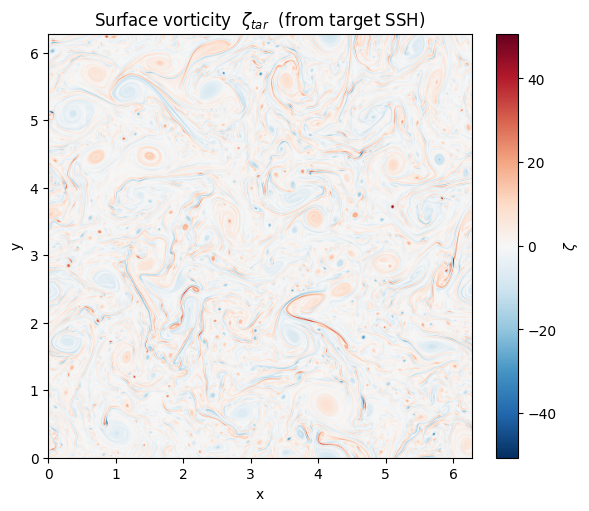

In [85]:
# ── Surface vorticity of the target SSH (QG truth) ───────────────────────────

def compute_zeta_from_phi(phi_hat):
    """Compute surface velocity and vorticity from a streamfunction in spectral space."""
    u, v = calculate_surface_u(phi_hat, mu, inv_mu, kx, ky, K2, inv_K2, epsilon, Bu)
    zeta = jnp.real(jnp.fft.ifft2(
        1j * kx * jnp.fft.fft2(v) - 1j * ky * jnp.fft.fft2(u)
    ))
    return u, v, zeta
_, _, zeta_obs = compute_zeta_from_phi(phi0_s_hat)

vmax_z = float(jnp.max(jnp.abs(zeta_obs)))

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
im = ax.imshow(zeta_obs, origin='lower', cmap='RdBu_r',
               vmin=-vmax_z, vmax=vmax_z,
               extent=[0, float(Lx), 0, float(Ly)])
ax.set_title(r"Surface vorticity  $\zeta_{tar}$  (from target SSH)")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.colorbar(im, ax=ax, fraction=0.046, label=r"$\zeta$")
plt.show()


# Build the Perturbed Surface Sea Height

In [86]:
# Input subfiles
%reload_ext autoreload
%autoreload 2

rng_key = jax.random.PRNGKey(42)

print(epsilon)

from perturbation_setup_v3 import build_all_perturbations, print_rms_table
cases = build_all_perturbations(
    eta_tar, eta_tar_hat, kx, ky, K, K2, inv_K2,
    mu, inv_mu, Bu, epsilon, X, Y, Lx, Ly, rng_key
)

# For C1 case specifically
# from perturbation_setup_C1 import build_C1_perturbations, print_rms_table as print_C1_table
# cases = build_C1_perturbations(eta_tar, K, epsilon, rng_key)
# print_C1_table(cases, eta_tar, epsillon)

# For C2 case specifically
# from perturbation_setup_C2 import build_C2_perturbations, print_rms_table as print_C2_table
# cases = build_C2_perturbations(eta_tar, K, epsilon, rng_key)
# print_C2_table(cases, eta_tar, epsilon)

# For C3 case
# from perturbation_setup_C3 import build_C3_perturbations, print_rms_table as print_C3_table
# cases = build_C3_perturbations(eta_tar, K, epsilon, rng_key)
# print_C3_table(cases, eta_tar, epsilon)



print(f"  max |phi0_s|     = {jnp.max(jnp.abs(phi0_s)):.6f}")
print()

for name, (eta_perturb, eta_obs) in cases.items():
    print(f"[{name}]")
    print(f"  max |perturb|  = {jnp.max(jnp.abs(eta_perturb)):.6f}")
    print(f"  max |eta_obs| = {jnp.max(jnp.abs(eta_obs)):.6f}")
    print(f"  ratio (perturb / phi0_s) = {jnp.max(jnp.abs(eta_perturb)) / jnp.max(jnp.abs(phi0_s)):.4f}")
    print()

0.01
  max |phi0_s|     = 0.158754

[A1_nothing]
  max |perturb|  = 0.000000
  max |eta_obs| = 0.235779
  ratio (perturb / phi0_s) = 0.0000

[C1_high_k_noise]
  max |perturb|  = 0.001753
  max |eta_obs| = 0.235274
  ratio (perturb / phi0_s) = 0.0110

[C2_low_k_noise]
  max |perturb|  = 0.001019
  max |eta_obs| = 0.235585
  ratio (perturb / phi0_s) = 0.0064

[C3_no_cutoff_noise]
  max |perturb|  = 0.001021
  max |eta_obs| = 0.235582
  ratio (perturb / phi0_s) = 0.0064



# Inversion Part

First setup the initial guess field. The initial guess should be the QG surface streamfunction which is the same as QG surface sea height

In [87]:
# Initial Guess
@jit
def loss_fn(phi0_flat, target):
    phi0_2d = phi0_flat.reshape(Nx, Ny)
    return cost_function_fmin(
        phi0_2d, kx, ky, mu, inv_mu, Bu, Ro_sys, K2, inv_K2, target
    )
grad_fn = jit(jax.grad(loss_fn))

phi0_s_guess = ssh_qg # The initial guess is just the surface streamfunction

# Print the initial loss function for A1
perturb_A1, eta_obs_A1 = cases['A1_nothing']
print()
print(f"  Initial loss (A1_nothing) = {loss_init:.6e}")


  Initial loss (A1_nothing) = 1.050354e-29


In [88]:
# ── Benchmark: Inversion across all perturbation cases ──

num_iterations = 100000
loss_threshold = 1e-3 * epsilon ** 2
print(loss_threshold)
grad_threshold = 1e-2 * epsilon ** 2
log_every      = 1000
stagnation_ratio = 0.9999  # break if loss_new / loss_prev > this ratio over log_every steps

# Storage for results
benchmark_results = {}   # {name: {iters, elapsed, final_loss, final_grad, loss_history}}
phi0_s_optimals   = {}   # {name: (Nx, Ny) optimal streamfunction}

phi0_flat_guess = phi0_s_guess.ravel()


# Define loss/grad ONCE — pass target as argument so JAX compiles only once
@jit
def loss_fn(phi0_flat, target):
    phi0_2d = phi0_flat.reshape(Nx, Ny)
    return cost_function_fmin(
        phi0_2d, kx, ky, mu, inv_mu, Bu, Ro_sys, K2, inv_K2, target
    )

grad_fn = jit(jax.grad(loss_fn))

# cases[name] = (perturbation, eta_obs) where eta_obs = ssh_qg + perturbation
# (both in physical space; see build_all_perturbations with perturb_streamfunction=False)
for case_name, (perturb, eta_obs) in cases.items():
    print(f"\n{'='*60}")
    print(f"  Case: {case_name}")
    print(f"{'='*60}")

    # Loss function expects the SSH target in spectral space
    eta_s_hat_obs = jnp.fft.fft2(eta_obs)

    solver = jaxopt.LBFGS(fun=loss_fn, maxiter=num_iterations, tol=1e-8)
    state  = solver.init_state(phi0_flat_guess, eta_s_hat_obs)
    params = phi0_flat_guess

    loss_history = []
    t0 = time.time()
    converged_iter = num_iterations
    prev_checkpoint_loss = None

    for it in range(num_iterations):
        params, state = solver.update(params, state, eta_s_hat_obs)
        loss_val = float(loss_fn(params, eta_s_hat_obs))
        g_norm = float(jnp.linalg.norm(grad_fn(params, eta_s_hat_obs)))
        loss_history.append(loss_val)

        if (it + 1) % log_every == 0 or it == 0:
            print(f"  Iter {it+1:5d} | Loss = {loss_val:.6e} | |grad| = {g_norm:.6e}")
            if prev_checkpoint_loss is not None and prev_checkpoint_loss > 0:
                ratio = loss_val / prev_checkpoint_loss
                if ratio > stagnation_ratio:
                    print(f"  ** Stagnated at iter {it+1}  (loss ratio = {ratio:.6f} > {stagnation_ratio})")
                    converged_iter = it + 1
                    break
            prev_checkpoint_loss = loss_val

        if loss_val < loss_threshold:
            print(f"  ** Converged (loss) at iter {it+1}  (Loss = {loss_val:.6e}, |grad| = {g_norm:.6e})")
            converged_iter = it + 1
            break

        if g_norm < grad_threshold:                                             # ← add this block
            print(f"  ** Converged (|grad|) at iter {it+1}  (Loss = {loss_val:.6e}, |grad| = {g_norm:.6e})")
            converged_iter = it + 1
            break

    elapsed = time.time() - t0

    phi0_s_optimals[case_name] = params.reshape(Nx, Ny)
    benchmark_results[case_name] = {
        'iters':        converged_iter,
        'elapsed':      elapsed,
        'final_loss':   loss_val,
        'final_grad':   float(jnp.linalg.norm(grad_fn(params, eta_s_hat_obs))),
        'loss_history': loss_history,
    }

    print(f"  Done: {converged_iter} iters, {elapsed:.1f}s, final loss = {loss_val:.4e}")

print("\n\nAll cases complete.")


1.0000000000000001e-07

  Case: A1_nothing
  Iter     1 | Loss = 1.377061e-26 | |grad| = 2.119801e-11
  ** Converged (loss) at iter 1  (Loss = 1.377061e-26, |grad| = 2.119801e-11)
  Done: 1 iters, 5.0s, final loss = 1.3771e-26

  Case: C1_high_k_noise
  Iter     1 | Loss = 5.472145e-02 | |grad| = 6.414800e+01
  Iter  1000 | Loss = 4.182723e-03 | |grad| = 1.164320e+00
  Iter  2000 | Loss = 4.123873e-03 | |grad| = 9.451959e-01
  Iter  3000 | Loss = 4.103828e-03 | |grad| = 6.354671e-01


JaxRuntimeError: INTERNAL: Buffer Definition Event: Error preparing computation: Out of memory allocating 71303168 bytes.

# Now plot the Result

Case                           Init Loss   Iters   Time (s)     Final Loss   Final |grad|
------------------------------------------------------------------------------------------
A1_nothing                    2.7445e-29       1        1.7     2.7445e-29     4.8546e-14
C1_high_k_noise               4.1739e-03   12000      205.4     2.4327e-04     5.1120e-04
C2_low_k_noise                4.2022e-03    2000       50.3     3.3524e-03     1.8427e-04
C3_no_cutoff_noise            4.2021e-03    2000       42.1     3.3517e-03     3.2104e-04


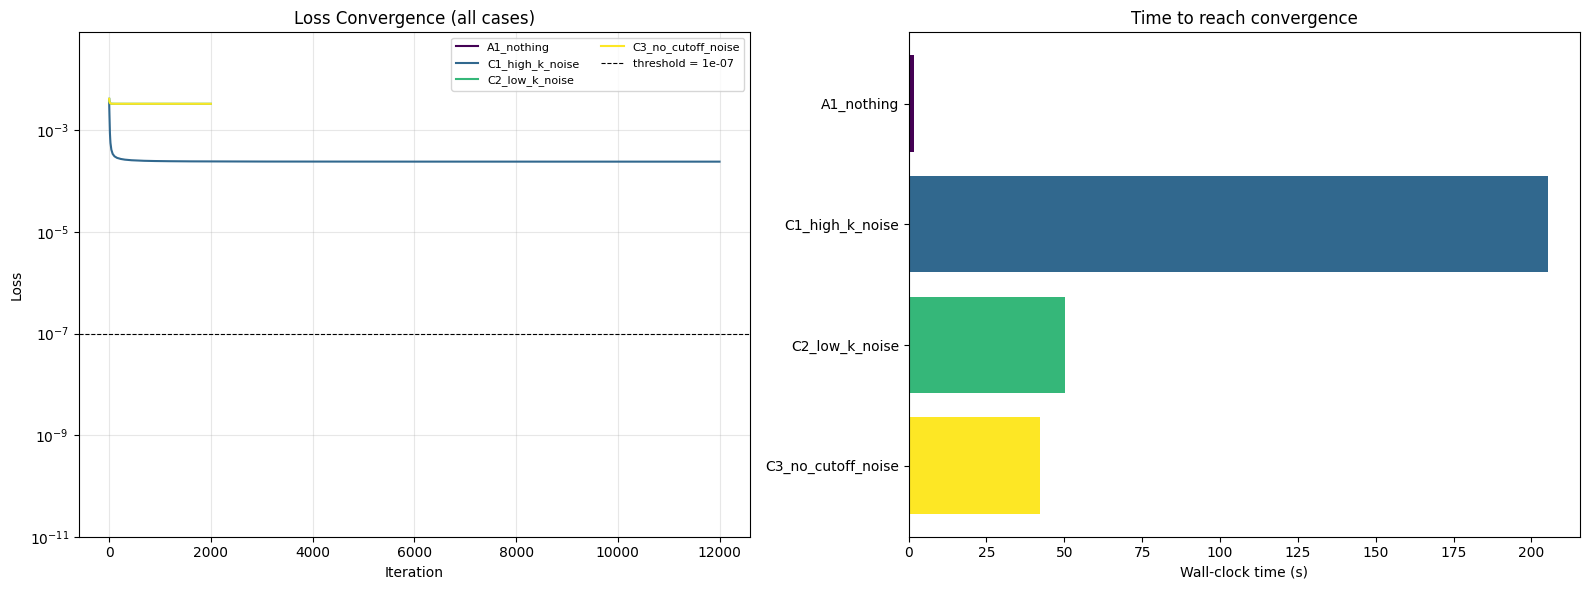

In [71]:
# ── Summary table (with initial loss) ──
print(f"{'Case':<25} {'Init Loss':>14} {'Iters':>7} {'Time (s)':>10} {'Final Loss':>14} {'Final |grad|':>14}")
print("-" * 90)
for name, r in benchmark_results.items():
    init_loss = r['loss_history'][0] if r['loss_history'] else float('nan')
    print(f"{name:<25} {init_loss:>14.4e} {r['iters']:>7d} {r['elapsed']:>10.1f} {r['final_loss']:>14.4e} {r['final_grad']:>14.4e}")

# ── Loss convergence curves (all cases on one plot) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Dynamic colour assignment: sequential colormap shaded by case order.
# Works for any sweep (C2_kcut_*, C3_slope_*, etc.) — no hardcoding.
case_names = list(benchmark_results.keys())
n_cases    = len(case_names)
cmap       = plt.cm.viridis                       # swap for plasma/Blues/etc. if you prefer
case_colors = {name: cmap(i / max(n_cases - 1, 1))
               for i, name in enumerate(case_names)}

for name, r in benchmark_results.items():
    ax1.semilogy(r['loss_history'], label=name, color=case_colors[name], linewidth=1.5)

ax1.axhline(loss_threshold, color='k', linestyle='--', linewidth=0.8, label=f'threshold = {loss_threshold:.0e}')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Convergence (all cases)')
ax1.legend(fontsize=8, ncol=2)
# ax1.set_xscale('log')
ax1.set_ylim(bottom=1e-11)
ax1.grid(True, which='both', alpha=0.3)

# ── Bar chart: wall-clock time to convergence ──
times  = [benchmark_results[n]['elapsed'] for n in case_names]
colors = [case_colors[n] for n in case_names]

ax2.barh(case_names, times, color=colors)
ax2.set_xlabel('Wall-clock time (s)')
ax2.set_title('Time to reach convergence')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


# Result Analysis

For most of the case, the convergent is really fast. However although the final gradient is near 0, actually the lost function is not. Indicating the SQG+1 model is not capable of reconstructing a surface sea height exactly equals to the perturbed field. This is reasonable since the perturbation we added is not QG. I would compare the SSH_target with the inversed ssh. 

Available cases:
  [0] A1_nothing              final_loss = 2.744e-29  |grad| = 4.855e-14
  [1] C1_high_k_noise         final_loss = 2.433e-04  |grad| = 5.112e-04
  [2] C2_low_k_noise          final_loss = 3.352e-03  |grad| = 1.843e-04
  [3] C3_no_cutoff_noise      final_loss = 3.352e-03  |grad| = 3.210e-04

── A1_nothing ──
  rms(target)   = 5.716629e-02
  rms(residual) = 4.250603e-17
  rel error     = 0.0000%


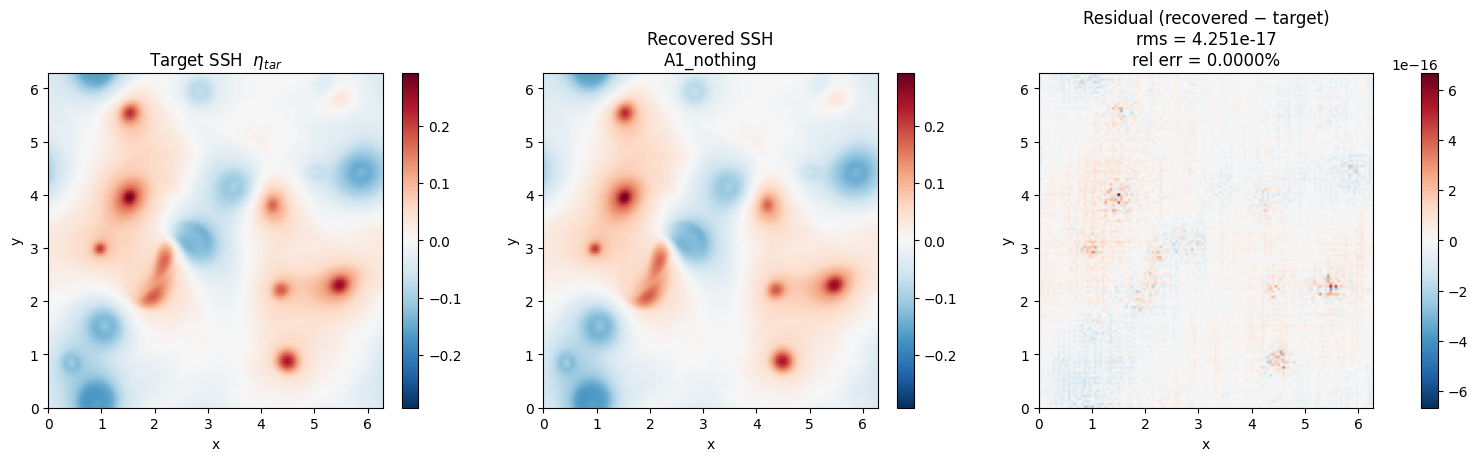

── C1_high_k_noise ──
  rms(target)   = 5.716629e-02
  rms(residual) = 5.585284e-04
  rel error     = 0.9770%


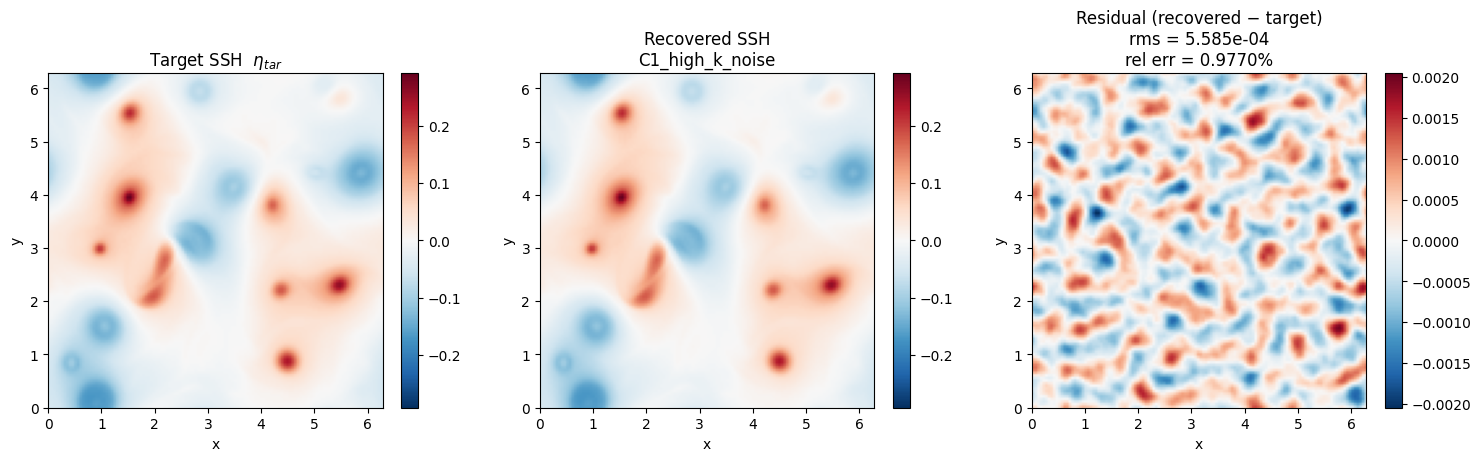

── C2_low_k_noise ──
  rms(target)   = 5.716629e-02
  rms(residual) = 3.495507e-04
  rel error     = 0.6115%


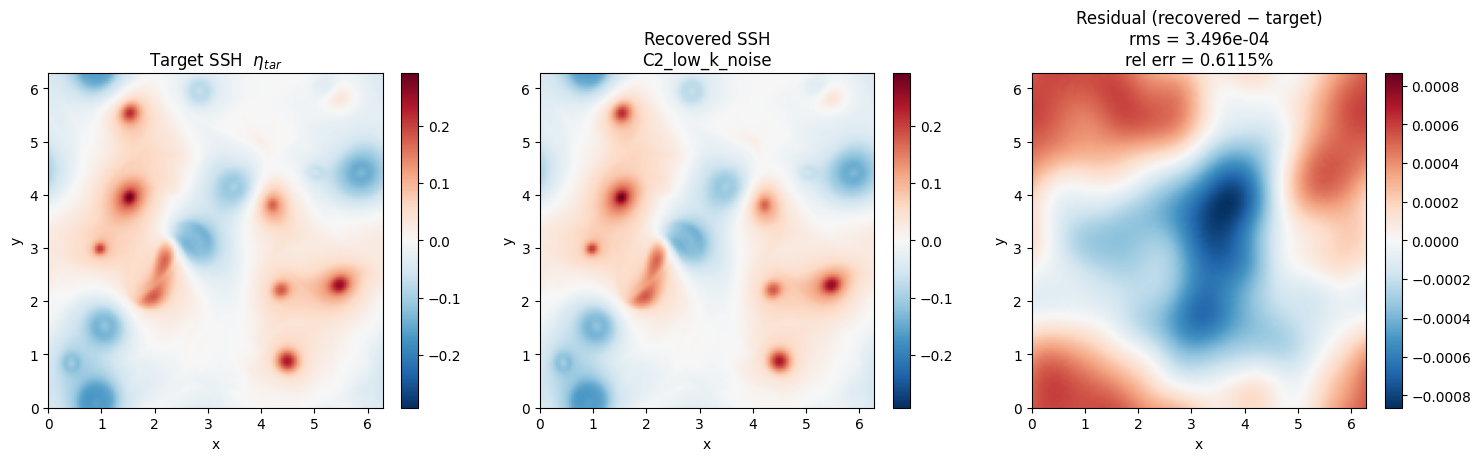

── C3_no_cutoff_noise ──
  rms(target)   = 5.716629e-02
  rms(residual) = 3.496083e-04
  rel error     = 0.6116%


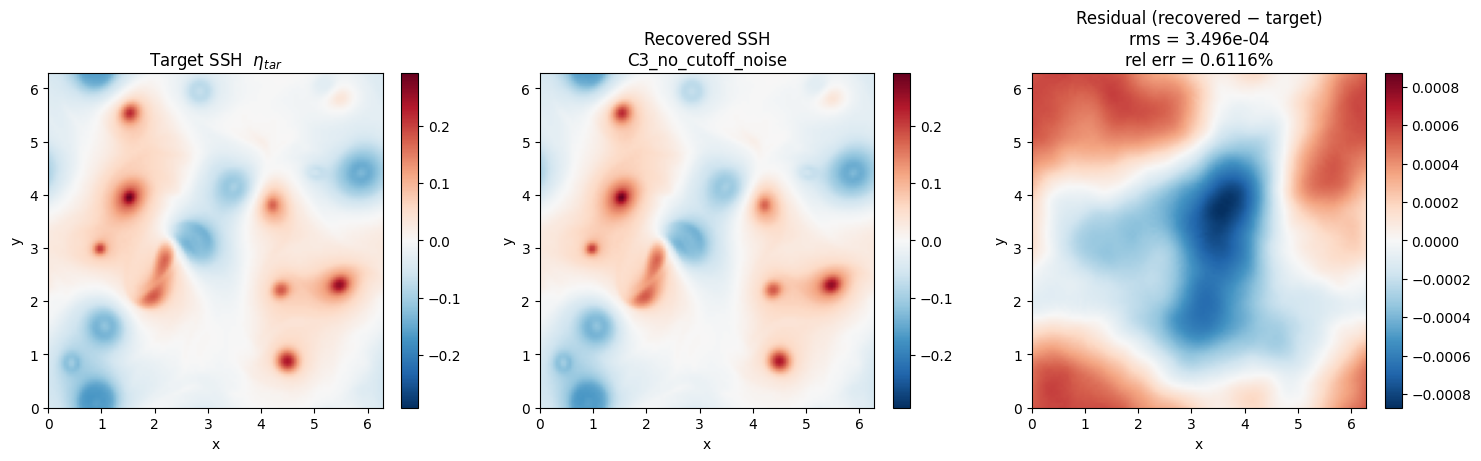

In [ ]:
import os
from tkinter import Tk, filedialog

store_all = False

# If store_all, ask for a folder once; otherwise plots just show inline
save_dir = None
if store_all:
    root = Tk(); root.withdraw(); root.attributes("-topmost", True)
    save_dir = filedialog.askdirectory(title="Choose folder to save case plots")
    root.destroy()
    if not save_dir:
        print("No folder selected — plots will be shown but not saved.")
    else:
        os.makedirs(save_dir, exist_ok=True)
        print(f"Saving plots to: {save_dir}\n")

# Summary header
print("Available cases:")
for i, name in enumerate(cases.keys()):
    r = benchmark_results[name]
    print(f"  [{i}] {name:<22}  final_loss = {r['final_loss']:.3e}  |grad| = {r['final_grad']:.3e}")
print()

# Loop over every case
for case_name in cases.keys():
    perturb, eta_obs_phys = cases[case_name]
    phi0_opt = phi0_s_optimals[case_name]

    # Forward SQG+1 SSH from the optimal streamfunction
    phi0_opt_hat = jnp.fft.fft2(phi0_opt)
    eta_opt_hat  = forward_ssh(phi0_opt_hat, kx, ky,
                               mu, inv_mu, K2, inv_K2, Bu, Ro_sys)
    eta_opt_phys = jnp.real(jnp.fft.ifft2(eta_opt_hat))

    residual     = eta_opt_phys - eta_tar
    rms_target   = float(jnp.sqrt(jnp.mean(eta_tar ** 2)))
    rms_residual = float(jnp.sqrt(jnp.mean(residual ** 2)))
    rel_err      = rms_residual / rms_target if rms_target > 0 else float('nan')

    print(f"── {case_name} ──")
    print(f"  rms(target)   = {rms_target:.6e}")
    print(f"  rms(residual) = {rms_residual:.6e}")
    print(f"  rel error     = {rel_err:.4%}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

    vmax = float(jnp.max(jnp.abs(eta_tar)))
    im0 = axes[0].imshow(eta_tar, origin='lower', cmap='RdBu_r',
                         vmin=-vmax, vmax=vmax,
                         extent=[0, float(Lx), 0, float(Ly)])
    axes[0].set_title(r"Target SSH  $\eta_{tar}$")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(eta_opt_phys, origin='lower', cmap='RdBu_r',
                         vmin=-vmax, vmax=vmax,
                         extent=[0, float(Lx), 0, float(Ly)])
    axes[1].set_title(f"Recovered SSH\n{case_name}")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    rvmax = float(jnp.max(jnp.abs(residual)))
    im2 = axes[2].imshow(residual, origin='lower', cmap='RdBu_r',
                         vmin=-rvmax, vmax=rvmax,
                         extent=[0, float(Lx), 0, float(Ly)])
    axes[2].set_title(f"Residual (recovered − target)\nrms = {rms_residual:.3e}\nrel err = {rel_err:.4%}")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    for ax in axes:
        ax.set_xlabel("x"); ax.set_ylabel("y")

    if save_dir:
        safe_name = case_name.replace("/", "_").replace(" ", "_")
        fpath = os.path.join(save_dir, f"{safe_name}.png")
        fig.savefig(fpath, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close(fig)

# Compare the Result

What is actually interested would be the QG field, $u_qg$. The perturbation added would be noise that influence the inversion but not what we are interested in. 

Below I compare the surface velocity field from the optimal variable $\Phi^0$ and input into the SQG+1 model and the velocity field from the original QG simulation. 

── A1_nothing ──  rel. rms(ζ err) = 0.0000%


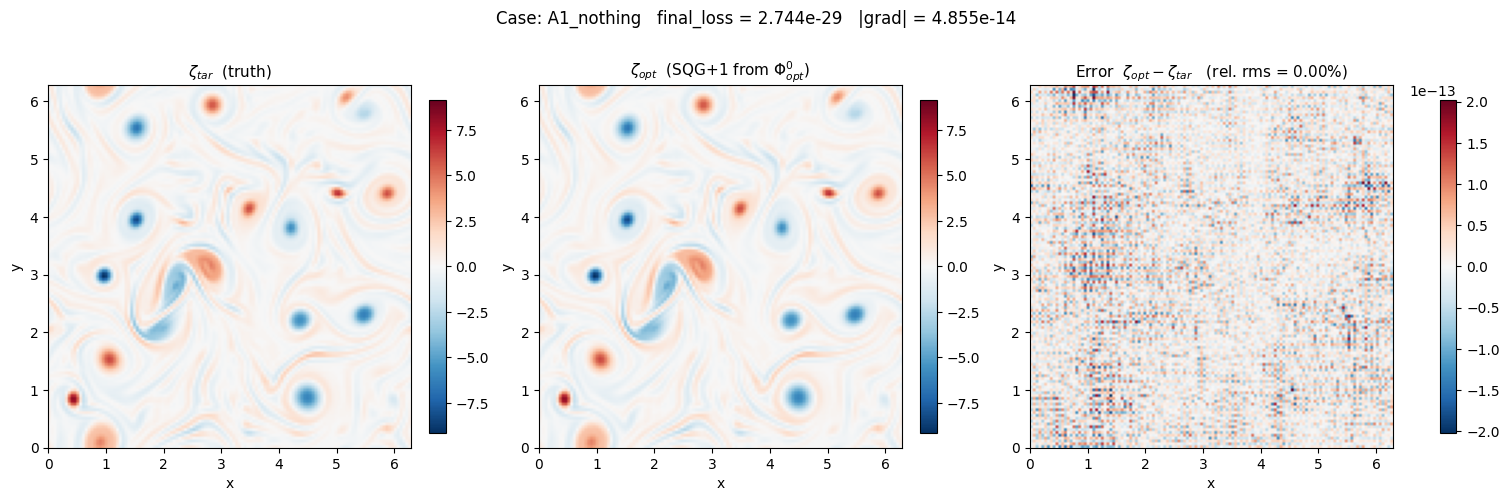

── C1_high_k_noise ──  rel. rms(ζ err) = 47.3996%


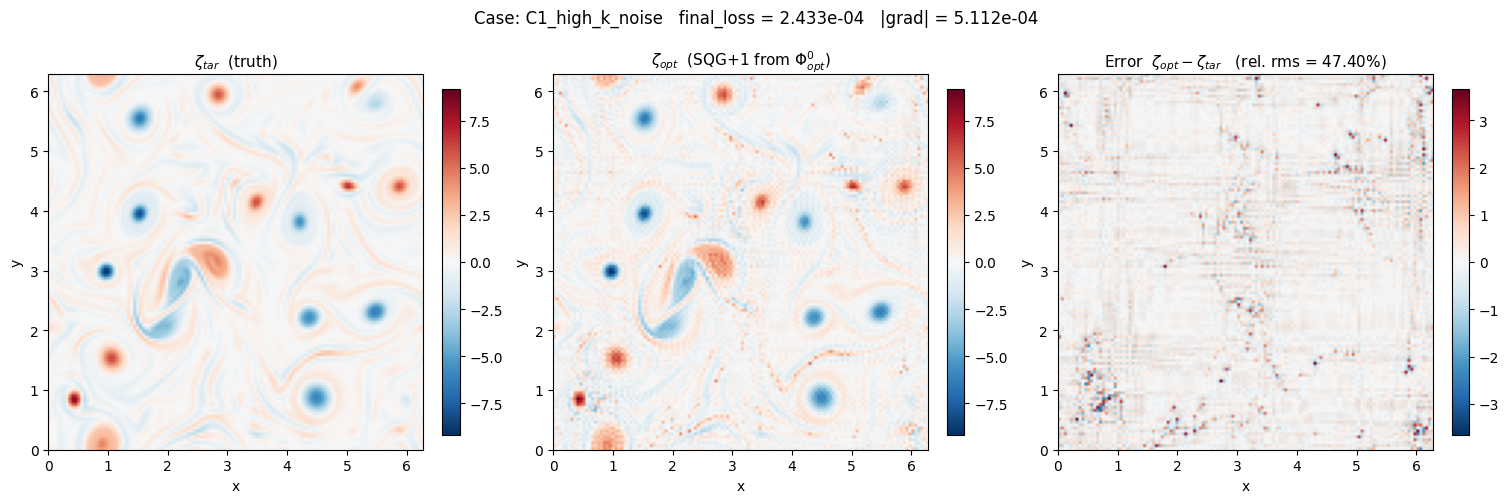

── C2_low_k_noise ──  rel. rms(ζ err) = 13.8729%


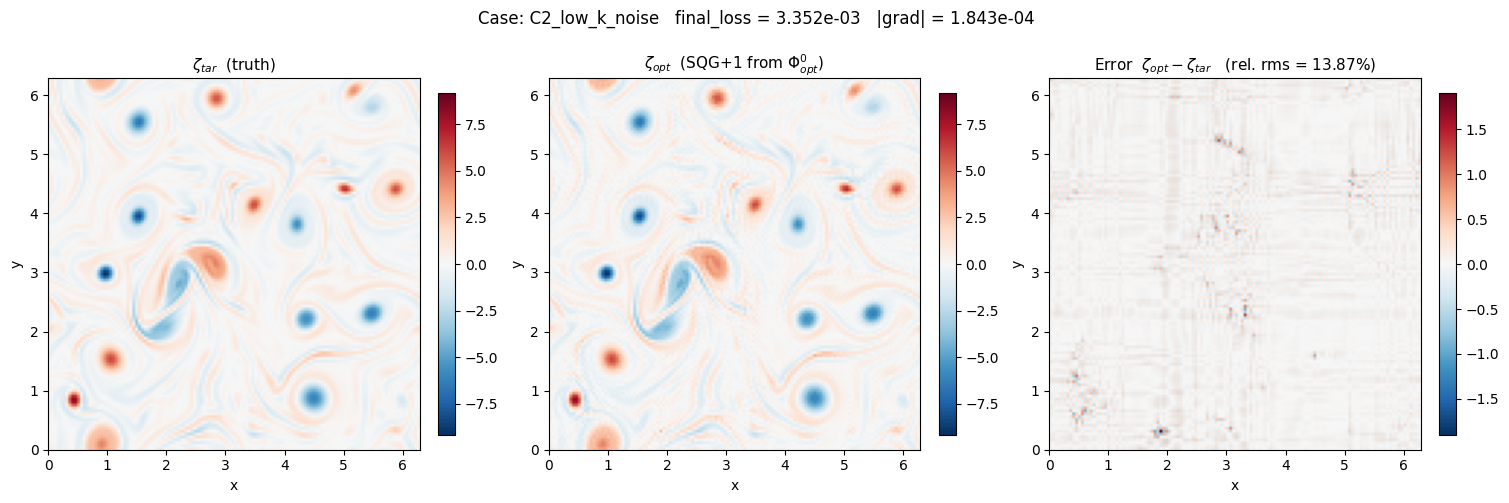

── C3_no_cutoff_noise ──  rel. rms(ζ err) = 14.0400%


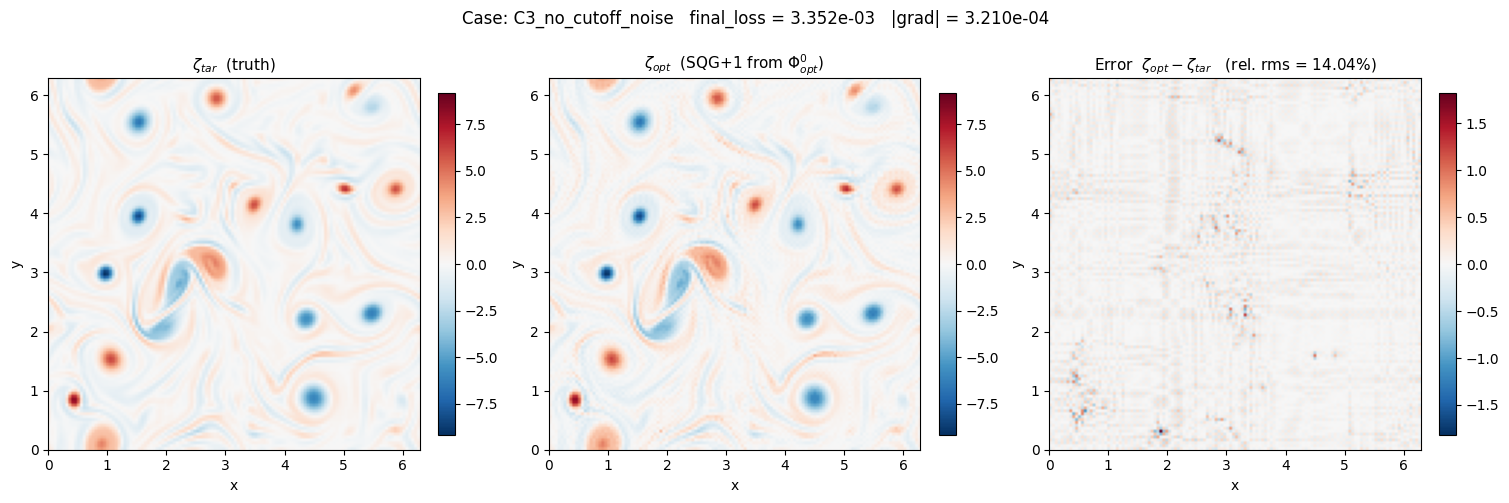

In [73]:
import os
from tkinter import Tk, filedialog

store_all = False

# ── Ask for output folder once if storing ─────────────────────────────────────
save_dir = None
if store_all:
    root = Tk(); root.withdraw(); root.attributes("-topmost", True)
    save_dir = filedialog.askdirectory(title="Choose folder to save vorticity plots")
    root.destroy()
    if not save_dir:
        print("No folder selected — plots will be shown but not saved.")
    else:
        os.makedirs(save_dir, exist_ok=True)
        print(f"Saving plots to: {save_dir}\n")


# ── Per-case recovered vorticity from SQG+1 velocity ──────────────────────────
def compute_zeta_from_phi(phi_hat):
    u, v = calculate_surface_u(phi_hat, mu, inv_mu, kx, ky, K2, inv_K2, epsilon, Bu)
    zeta = jnp.real(jnp.fft.ifft2(
        1j * kx * jnp.fft.fft2(v) - 1j * ky * jnp.fft.fft2(u)
    ))
    return u, v, zeta


# ── Reference (target) vorticity — computed once ─────────────────────────────
u_tar, v_tar, zeta_tar = compute_zeta_from_phi(phi0_s_hat)
rms_zeta_tar = float(jnp.sqrt(jnp.mean(zeta_tar ** 2)))


# ── Loop over every case ──────────────────────────────────────────────────────
extent = [0, float(Lx), 0, float(Ly)]
vmax_z = float(jnp.max(jnp.abs(zeta_tar)))

for case_name in cases.keys():
    phi0_opt_hat = jnp.fft.fft2(phi0_s_optimals[case_name])
    u_opt, v_opt, zeta_opt = compute_zeta_from_phi(phi0_opt_hat)

    zeta_err = zeta_opt - zeta_tar
    rel_zeta_err = float(jnp.sqrt(jnp.mean(zeta_err ** 2))) / rms_zeta_tar

    print(f"── {case_name} ──  rel. rms(ζ err) = {rel_zeta_err:.4%}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

    titles = [
        r"$\zeta_{tar}$  (truth)",
        r"$\zeta_{opt}$  (SQG+1 from $\Phi^0_{opt}$)",
        rf"Error  $\zeta_{{opt}} - \zeta_{{tar}}$   (rel. rms = {rel_zeta_err:.2%})",
    ]
    fields = [zeta_tar, zeta_opt, zeta_err]

    for ax, field, title in zip(axes, fields, titles):
        vmax = vmax_z if "Error" not in title else float(jnp.max(jnp.abs(zeta_err)))
        im = ax.imshow(field, origin='lower', cmap='RdBu_r',
                       vmin=-vmax, vmax=vmax, extent=extent)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("x"); ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle(
        f"Case: {case_name}   "
        f"final_loss = {benchmark_results[case_name]['final_loss']:.3e}   "
        f"|grad| = {benchmark_results[case_name]['final_grad']:.3e}",
        fontsize=12
    )

    if save_dir:
        safe_name = case_name.replace("/", "_").replace(" ", "_")
        fpath = os.path.join(save_dir, f"vorticity_{safe_name}.png")
        fig.savefig(fpath, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close(fig)




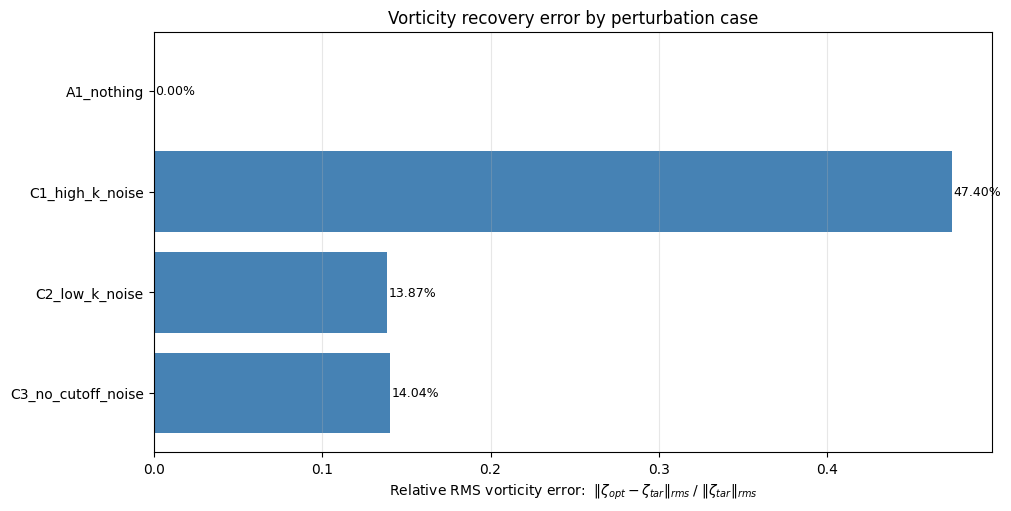

In [74]:
# ── Bar chart: relative RMS vorticity error across cases ──────────────────────
case_names_zeta = []
rel_errors_zeta = []

for case_name in cases.keys():
    phi0_opt_hat = jnp.fft.fft2(phi0_s_optimals[case_name])
    _, _, zeta_opt = compute_zeta_from_phi(phi0_opt_hat)
    zeta_err = zeta_opt - zeta_tar
    rel_err = float(jnp.sqrt(jnp.mean(zeta_err ** 2))) / rms_zeta_tar
    case_names_zeta.append(case_name)
    rel_errors_zeta.append(rel_err)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
bars = ax.barh(case_names_zeta, rel_errors_zeta, color='steelblue')
ax.set_xlabel(r"Relative RMS vorticity error:  $\| \zeta_{opt} - \zeta_{tar} \|_{rms} \;/\; \| \zeta_{tar} \|_{rms}$")
ax.set_title("Vorticity recovery error by perturbation case")
ax.invert_yaxis()

for bar, val in zip(bars, rel_errors_zeta):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.2%}", va='center', fontsize=9)

ax.grid(True, axis='x', alpha=0.3)
plt.show()

# Evaluation Metric?

I propose we can may plot the spectral error decomposition 

$$ E(k) = \frac{|\hat{\xi}_{opt} - \hat{\xi}_{qg}|^2}{|\hat{\xi_{qg}}|^2} $$

This seperates the low-k error and High-k error. 

1.0


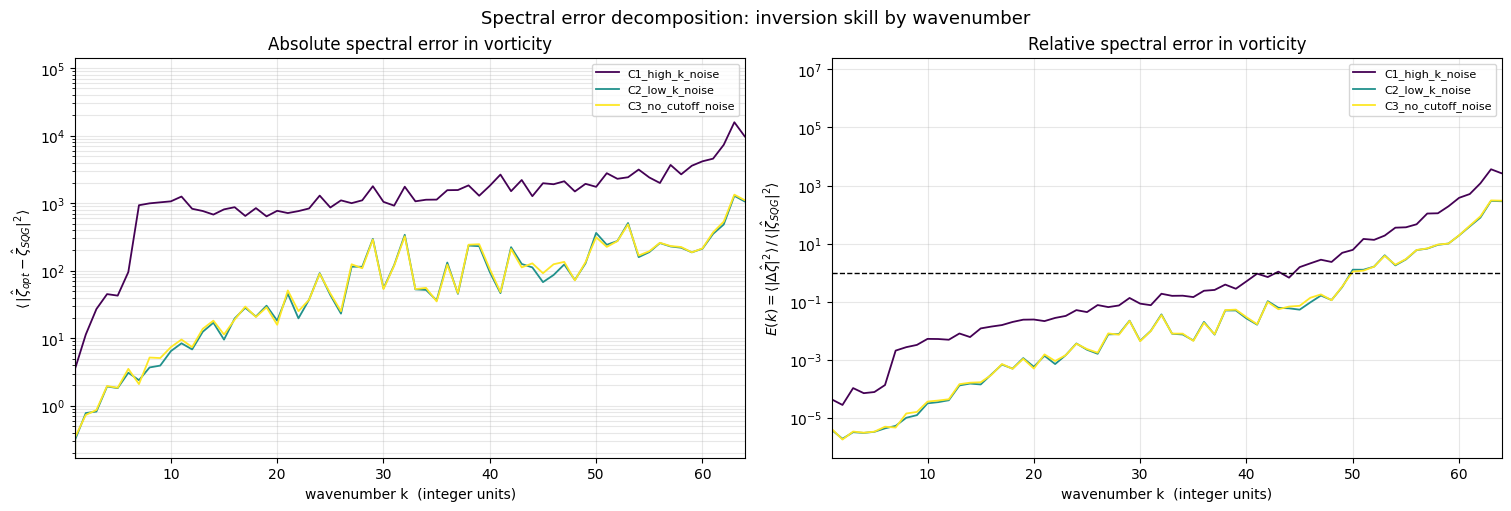

In [77]:
import matplotlib.pyplot as plt
import numpy as np

def azimuthal_spectrum(field_2d, K, dk):
    """
    Azimuthal average of a 2D spectral field, binned by integer wavenumber.
    Returns k_integers (1D) and the binned spectrum.
    """
    K_np     = np.array(K)
    field_np = np.array(np.real(field_2d))
    k_int    = np.round(K_np / dk).astype(int)
    k_max    = k_int.max()

    spectrum = np.zeros(k_max + 1)
    counts   = np.zeros(k_max + 1)
    np.add.at(spectrum, k_int.ravel(), field_np.ravel())
    np.add.at(counts,   k_int.ravel(), 1)

    counts   = np.where(counts > 0, counts, np.nan)
    spectrum = spectrum / counts
    k_axis   = np.arange(k_max + 1)
    return k_axis, spectrum


def spectral_error(phi0_opt_hat, phi0_s_hat, mu, inv_mu, kx, ky,
                   K, K2, inv_K2, Ro_sys, Bu, dk):
    """
    Azimuthally-averaged relative spectral error in surface vorticity.
    Reference is the SQG+1 surface vorticity built from the TRUE phi0_s_hat
    using the same operator as zeta_opt (calculate_surface_u + spectral curl),
    so a perfect recovery (phi0_opt = phi0_s) gives zero error.
        E(k) = <|ζ̂_opt(k) - ζ̂_sqg(k)|²> / <|ζ̂_sqg(k)|²>
    """
    u_true, v_true = calculate_surface_u(phi0_s_hat, mu, inv_mu,
                                         kx, ky, K2, inv_K2, Ro_sys, Bu)
    zeta_sqg_hat = 1j * kx * jnp.fft.fft2(v_true) - 1j * ky * jnp.fft.fft2(u_true)

    u_opt, v_opt = calculate_surface_u(phi0_opt_hat, mu, inv_mu,
                                       kx, ky, K2, inv_K2, Ro_sys, Bu)
    zeta_opt_hat = 1j * kx * jnp.fft.fft2(v_opt) - 1j * ky * jnp.fft.fft2(u_opt)

    err_power    = jnp.abs(zeta_opt_hat - zeta_sqg_hat) ** 2
    signal_power = jnp.abs(zeta_sqg_hat) ** 2

    k_axis, err_spec    = azimuthal_spectrum(err_power,    K, dk)
    _,      signal_spec = azimuthal_spectrum(signal_power, K, dk)

    with np.errstate(invalid='ignore', divide='ignore'):
        rel_spec = np.where(signal_spec > 1e-30, err_spec / signal_spec, np.nan)

    return k_axis, err_spec, signal_spec, rel_spec


# ── Infer dk directly from the kx grid used in the run ───────────────────────
# This matches whichever spectral_main convention is active (2π/Lx or 2π/Nx).
print(dk)

# Largest integer-k bin we expect to have signal in (Nyquist in grid-k units)
k_nyquist = int(round((Nx // 2) * (float(2.0 * jnp.pi / Nx)) / dk))  # safe upper bound
k_plot_max = Nx // 2

# ── SQG+1 signal spectrum (reference, same for every case) ──────────────────
u_true_ref, v_true_ref = calculate_surface_u(phi0_s_hat, mu, inv_mu,
                                             kx, ky, K2, inv_K2, Ro_sys, Bu)
zeta_sqg_hat = 1j * kx * jnp.fft.fft2(v_true_ref) - 1j * ky * jnp.fft.fft2(u_true_ref)
k_axis_ref, signal_spec = azimuthal_spectrum(jnp.abs(zeta_sqg_hat) ** 2, K, dk)

# ── Colour by case, robust to any naming (C1/C2/C3/E/v2) ─────────────────────
CASES_TO_PLOT = [name for name in cases.keys() if not name.startswith("A1")]
cmap   = plt.get_cmap('viridis', max(len(CASES_TO_PLOT), 2))
colors = {name: cmap(i) for i, name in enumerate(CASES_TO_PLOT)}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
ax_abs, ax_rel = axes

for name in CASES_TO_PLOT:
    if name not in phi0_s_optimals:
        print(f"  skipping {name}: no optimum stored")
        continue
    phi0_opt_hat = jnp.fft.fft2(phi0_s_optimals[name])
    k_axis, err_spec, _, rel_spec = spectral_error(
        phi0_opt_hat, phi0_s_hat, mu, inv_mu,
        kx, ky, K, K2, inv_K2, Ro_sys, Bu, dk
    )
    ax_abs.semilogy(k_axis, err_spec, label=name, color=colors[name], lw=1.3)
    ax_rel.semilogy(k_axis, rel_spec, label=name, color=colors[name], lw=1.3)

for ax in axes:
    ax.set_xlabel("wavenumber k  (integer units)")
    ax.set_xlim(1, k_plot_max)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8, ncol=1, loc='best')

ax_abs.set_ylabel(r"$\langle\,|\hat{\zeta}_{opt} - \hat{\zeta}_{SQG}|^2\rangle$")
ax_abs.set_title("Absolute spectral error in vorticity")

ax_rel.set_ylabel(r"$E(k) = \langle|\Delta\hat{\zeta}|^2\rangle\,/\,\langle|\hat{\zeta}_{SQG}|^2\rangle$")
ax_rel.set_title("Relative spectral error in vorticity")
ax_rel.axhline(1.0, color='k', ls='--', lw=1)

fig.suptitle("Spectral error decomposition: inversion skill by wavenumber", fontsize=13)
plt.show()

In [56]:
import os
import dill
from tkinter import Tk, filedialog

to_save = {
    'benchmark_results': benchmark_results,
    'phi0_s_optimals':   phi0_s_optimals,
    'cases':             cases,
    'phi0_s':            phi0_s,
    'phi0_s_hat':        phi0_s_hat,
    'kx': kx, 'ky': ky, 'K': K, 'K2': K2, 'inv_K2': inv_K2,
    'mu': mu, 'inv_mu': inv_mu,
    'Ro': Ro, 'epsilon': epsilon, 'Bu': Bu,
    'Nx': Nx, 'Ny': Ny, 'Lx': Lx, 'Ly': Ly,
    'X': X, 'Y': Y,
}

DEFAULT_NAME = 'workspace_0413_run2_Ro_1e-3.pkl'

root = Tk(); root.withdraw(); root.attributes("-topmost", True)
save_path = filedialog.asksaveasfilename(
    title="Save workspace pickle",
    defaultextension=".pkl",
    initialfile=DEFAULT_NAME,
    filetypes=[("Pickle files", "*.pkl"), ("All files", "*.*")],
)
root.destroy()

if not save_path:
    print("Save cancelled — nothing written.")
else:
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    with open(save_path, 'wb') as f:
        dill.dump(to_save, f)
    print(f"Workspace saved to: {save_path}")


Workspace saved to: D:/Documents/College/Research/Oceangrophy/Shafer_Project/Output/Benchmark Result/0413/C2_Vary/Run1_Ro_1e-3/workspace_0413_run2_Ro_1e-3.pkl
